In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
data = pd.read_csv(
    "/content/amazon_ecommerce_1M.csv",
    low_memory=False
)

print(data.shape)
print(data.dtypes)

(692019, 20)
user_id                object
product_id             object
category               object
subcategory            object
brand                  object
price                 float64
discount              float64
final_price           float64
rating                float64
review_count            int64
stock                   int64
seller_id              object
seller_rating         float64
purchase_date          object
shipping_time_days      int64
location               object
device                 object
payment_method         object
is_returned            object
delivery_status        object
dtype: object


In [4]:
data.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692019 entries, 0 to 692018
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   user_id             692019 non-null  object 
 1   product_id          692019 non-null  object 
 2   category            692019 non-null  object 
 3   subcategory         692019 non-null  object 
 4   brand               692019 non-null  object 
 5   price               692019 non-null  float64
 6   discount            692019 non-null  float64
 7   final_price         692019 non-null  float64
 8   rating              692019 non-null  float64
 9   review_count        692019 non-null  int64  
 10  stock               692019 non-null  int64  
 11  seller_id           692019 non-null  object 
 12  seller_rating       692019 non-null  float64
 13  purchase_date       692019 non-null  object 
 14  shipping_time_days  692019 non-null  int64  
 15  location            692018 non-nul

In [6]:
data.isnull().sum()

,0
user_id,0
product_id,0
category,0
subcategory,0
brand,0
price,0
discount,0
final_price,0
rating,0
review_count,0


In [8]:
data.fillna(data.mean(numeric_only=True), inplace=True)

In [11]:
data[col] = data[col].fillna(data[col].mode()[0])
data = data.infer_objects(copy=False)

In [12]:
data.describe()

,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days
count,692019.000000,692019.000000,692019.000000,692019.000000,692019.000000,692019.000000,692019.000000,692019.000000
mean,13221.013132,29.006679,9938.463637,3.926668,32.640371,250.068479,3.749444,3.167234
std,18077.382529,14.690776,14276.452304,0.520132,43.426628,144.619479,0.722112,1.673136
min,200.040000,5.000000,101.460000,1.600000,0.000000,0.000000,2.500000,1.000000
25%,2701.160000,16.920000,1705.290000,3.600000,10.000000,125.000000,3.100000,2.000000
50%,4970.930000,28.070000,3789.600000,3.900000,20.000000,250.000000,3.700000,3.000000
75%,14125.175000,39.260000,10378.420000,4.300000,39.000000,375.000000,4.400000,5.000000
max,79999.700000,70.000000,75831.110000,5.000000,2673.000000,500.000000,5.000000,6.000000


In [18]:
data["purchase_date"] = pd.to_datetime(data["purchase_date"])
data["month"] = data["purchase_date"].dt.month
data["sales"] = data["final_price"]

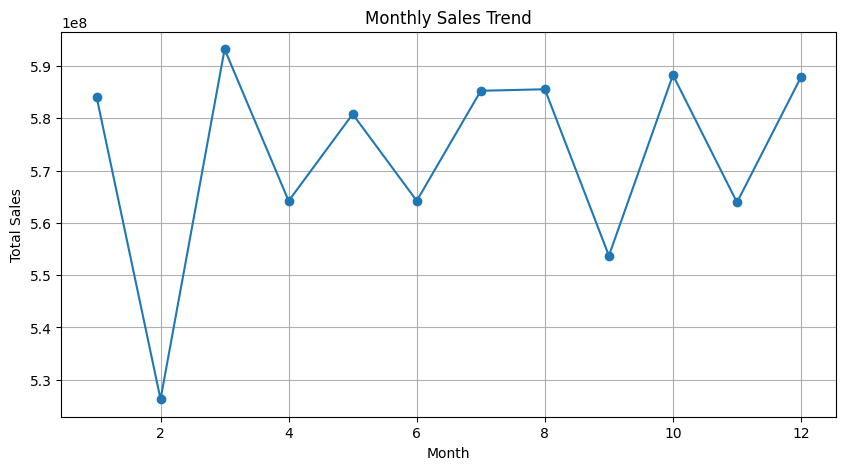

In [20]:
import matplotlib.pyplot as plt

monthly_sales = data.groupby("month")["sales"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = data[["price","discount","rating","review_count","stock","seller_rating"]]

y = data["final_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

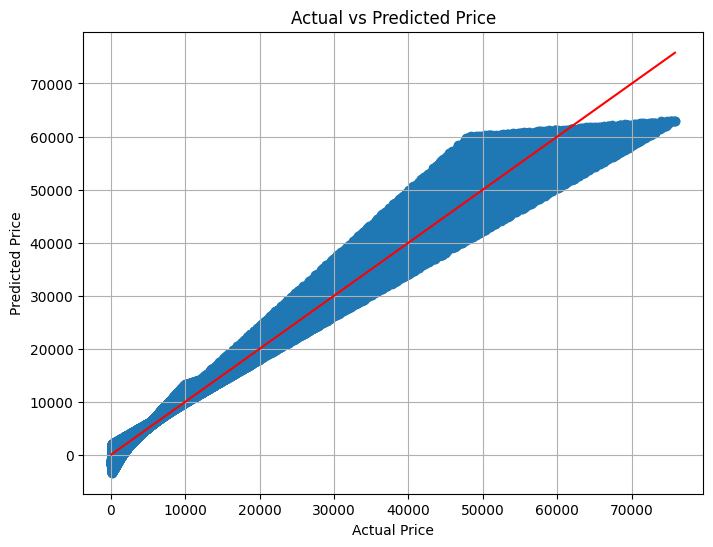

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.grid(True)
plt.show()

In [24]:
print(data.columns.tolist())

['user_id', 'product_id', 'category', 'subcategory', 'brand', 'price', 'discount', 'final_price', 'rating', 'review_count', 'stock', 'seller_id', 'seller_rating', 'purchase_date', 'shipping_time_days', 'location', 'device', 'payment_method', 'is_returned', 'delivery_status', 'month', 'sales']


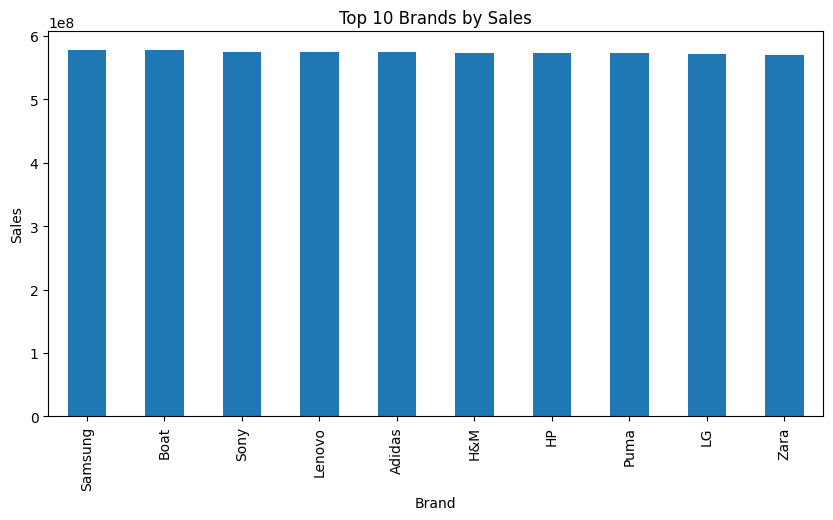

In [25]:
brand_sales = data.groupby("brand")["sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
brand_sales.plot(kind="bar")
plt.xlabel("Brand")
plt.ylabel("Sales")
plt.title("Top 10 Brands by Sales")
plt.show()

In [26]:
data["year"] = data["purchase_date"].dt.year
data["day"] = data["purchase_date"].dt.day
data["dayofweek"] = data["purchase_date"].dt.dayofweek

In [27]:
le = LabelEncoder()

categorical_cols = ["category","subcategory","brand","location","device","payment_method","delivery_status","user_id","product_id",
         "seller_id","purchase_date","year","month","day","dayofweek","is_returned"]

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

data["is_returned"] = data["is_returned"].astype(int)

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692019 entries, 0 to 692018
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   user_id             692019 non-null  int64  
 1   product_id          692019 non-null  int64  
 2   category            692019 non-null  int64  
 3   subcategory         692019 non-null  int64  
 4   brand               692019 non-null  int64  
 5   price               692019 non-null  float64
 6   discount            692019 non-null  float64
 7   final_price         692019 non-null  float64
 8   rating              692019 non-null  float64
 9   review_count        692019 non-null  int64  
 10  stock               692019 non-null  int64  
 11  seller_id           692019 non-null  int64  
 12  seller_rating       692019 non-null  float64
 13  purchase_date       692019 non-null  int64  
 14  shipping_time_days  692019 non-null  int64  
 15  location            692019 non-nul

In [30]:
X = data[
    ["category","subcategory","brand","price","discount","rating","review_count","stock","seller_rating",
        "shipping_time_days","location","device","payment_method","is_returned","delivery_status","year","month",
        "day","dayofweek"
    ]
]

In [31]:
y = data["final_price"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred = model.predict(X_test)

In [35]:
print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", mean_squared_error(y_test, y_pred) ** 0.5)

R2 Score : 0.9807708093317932
MAE : 1145.2049987486816
MSE : 3890910.364786185
RMSE : 1972.5390654651646


In [36]:
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(result.head(10))

   Actual Price  Predicted Price
0        813.45      -399.759345
1       1643.99       631.070761
2       9867.46     10442.010236
3       6210.82      6150.413845
4       4091.24      3829.109684
5       2971.42      4255.290636
6      45932.77     56636.506414
7      31816.77     32498.502948
8        866.00     -1017.857594
9       8821.09      8699.548610


In [37]:
accuracy = r2_score(y_test, y_pred) * 100
print(f"Model Accuracy: {accuracy:.2f}%")

Model Accuracy: 98.08%
